# Reproduce SMITH Figure 6c-d

This notebook regenerates manuscript-matched data panels from real H5AD inputs; it does not read the packaged reference-output tables. [Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/agent_section/05_SMITH_Agent_Evaluation_source.ipynb).

## Configure real inputs and fresh outputs

In [1]:
from pathlib import Path
import hashlib, json, os, subprocess, sys
import pandas as pd
from IPython.display import Image, display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
DATA_ROOT = Path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")).expanduser().resolve()
CASE_OUTPUT = OUTPUT_ROOT / 'agent'
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", 1))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cpu')

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


## Verify input files

In [2]:
inputs = ['agent/liver_merfish/adata_healthy_nucseq.h5ad', 'agent/liver_merfish/adata_healthy_merfish.h5ad', 'agent/references/PSC011_C1_visium.h5ad', 'agent/references/WSSS_F_IMMsp9838712_visium.h5ad']
rows = []
for relative in inputs:
    path = DATA_ROOT / relative
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Run scripts/download_tutorial_data.py first.")
    rows.append({"file": relative, "bytes": path.stat().st_size, "sha256": sha256_file(path)})
display(pd.DataFrame(rows))


,file,bytes,sha256
0,agent/liver_merfish/adata_healthy_nucseq.h5ad,1262101004,faa8897adfc86a436053c28e7d5012a422335a00f9faf3...
1,agent/liver_merfish/adata_healthy_merfish.h5ad,350386069,6b7fc5879a78b03002d94500ceffb3dcebef4cea82c29b...
2,agent/references/PSC011_C1_visium.h5ad,157609327,21f3710fd52fb842d24c2dee30c8be42a22f451935cdf2...
3,agent/references/WSSS_F_IMMsp9838712_visium.h5ad,314137660,c2f418c03d5792852d27210770ad4b094e9abb7c2fca9b...


## Run the workflow for Figure 6c-d

In [3]:
command = [sys.executable, str(ROOT / 'reproducibility/workflows/agent/run_tutorial.py'), "--data-root", str(DATA_ROOT), "--output-dir", str(CASE_OUTPUT), "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--reference', 'references/PSC011_C1_visium.h5ad', '--reference', 'references/WSSS_F_IMMsp9838712_visium.h5ad', '--panel-sizes', '32,64,128', '--training-seeds', '1,2', '--max-cells', '3000'] + ["--force"]
display_command = ["python", 'reproducibility/workflows/agent/run_tutorial.py', "--data-root", "data/tutorials", "--output-dir", "outputs/tutorials/agent", "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--reference', 'references/PSC011_C1_visium.h5ad', '--reference', 'references/WSSS_F_IMMsp9838712_visium.h5ad', '--panel-sizes', '32,64,128', '--training-seeds', '1,2', '--max-cells', '3000'] + ["--force"]
print(" ".join(display_command))
completed = subprocess.run(command, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if completed.returncode:
    print(completed.stdout)
    raise subprocess.CalledProcessError(completed.returncode, command)
manifest = json.loads((CASE_OUTPUT / "run_manifest.json").read_text())
print("Generated", manifest["manuscript_figure"], "data from fresh workflow outputs.")


python reproducibility/workflows/agent/run_tutorial.py --data-root data/tutorials --output-dir outputs/tutorials/agent --device cpu --epochs 1 --reference references/PSC011_C1_visium.h5ad --reference references/WSSS_F_IMMsp9838712_visium.h5ad --panel-sizes 32,64,128 --training-seeds 1,2 --max-cells 3000 --force


Generated Figure 6c-d data from fresh workflow outputs.


## Inspect newly generated figure data

In [4]:
for relative in ['figure_data/figure6_c_cell_type_accuracy.tsv', 'figure_data/figure6_d_merfish_expression.tsv']:
    path = CASE_OUTPUT / relative
    print(relative)
    display(pd.read_csv(path, sep="\t").head(20))


figure_data/figure6_c_cell_type_accuracy.tsv


,training_seed,panel_size,panel,cell_type_accuracy,panel_file
0,1,32,snRNA-seq,0.520794,/workspace/fanyimin/SMITH_package/outputs/figu...
1,1,32,snRNA-seq + 2 ST,0.545515,/workspace/fanyimin/SMITH_package/outputs/figu...
2,1,64,snRNA-seq,0.690189,/workspace/fanyimin/SMITH_package/outputs/figu...
3,1,64,snRNA-seq + 2 ST,0.616193,/workspace/fanyimin/SMITH_package/outputs/figu...
4,1,128,snRNA-seq,0.753180,/workspace/fanyimin/SMITH_package/outputs/figu...
5,1,128,snRNA-seq + 2 ST,0.661487,/workspace/fanyimin/SMITH_package/outputs/figu...
6,2,32,snRNA-seq,0.512554,/workspace/fanyimin/SMITH_package/outputs/figu...
7,2,32,snRNA-seq + 2 ST,0.480478,/workspace/fanyimin/SMITH_package/outputs/figu...
8,2,64,snRNA-seq,0.635439,/workspace/fanyimin/SMITH_package/outputs/figu...
9,2,64,snRNA-seq + 2 ST,0.546068,/workspace/fanyimin/SMITH_package/outputs/figu...


figure_data/figure6_d_merfish_expression.tsv


,training_seed,panel_size,panel,mean_merfish_expression,panel_file
0,1,32,snRNA-seq,0.268324,/workspace/fanyimin/SMITH_package/outputs/figu...
1,1,32,snRNA-seq + 2 ST,0.330286,/workspace/fanyimin/SMITH_package/outputs/figu...
2,1,64,snRNA-seq,0.243450,/workspace/fanyimin/SMITH_package/outputs/figu...
3,1,64,snRNA-seq + 2 ST,0.281675,/workspace/fanyimin/SMITH_package/outputs/figu...
4,1,128,snRNA-seq,0.233293,/workspace/fanyimin/SMITH_package/outputs/figu...
5,1,128,snRNA-seq + 2 ST,0.233394,/workspace/fanyimin/SMITH_package/outputs/figu...
6,2,32,snRNA-seq,0.240342,/workspace/fanyimin/SMITH_package/outputs/figu...
7,2,32,snRNA-seq + 2 ST,0.233222,/workspace/fanyimin/SMITH_package/outputs/figu...
8,2,64,snRNA-seq,0.254263,/workspace/fanyimin/SMITH_package/outputs/figu...
9,2,64,snRNA-seq + 2 ST,0.233391,/workspace/fanyimin/SMITH_package/outputs/figu...


## Draw panels from this run

The quick hosted run below has the manuscript axes and panel definitions, but only the methods/repeats actually executed above. Use the full command to regenerate the complete multi-method manuscript comparison.

{
  "png": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/agent/figures/figure6_c_d_reproduced.png",
  "pdf": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/agent/figures/figure6_c_d_reproduced.pdf",
  "svg": "/workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/agent/figures/figure6_c_d_reproduced.svg"
}


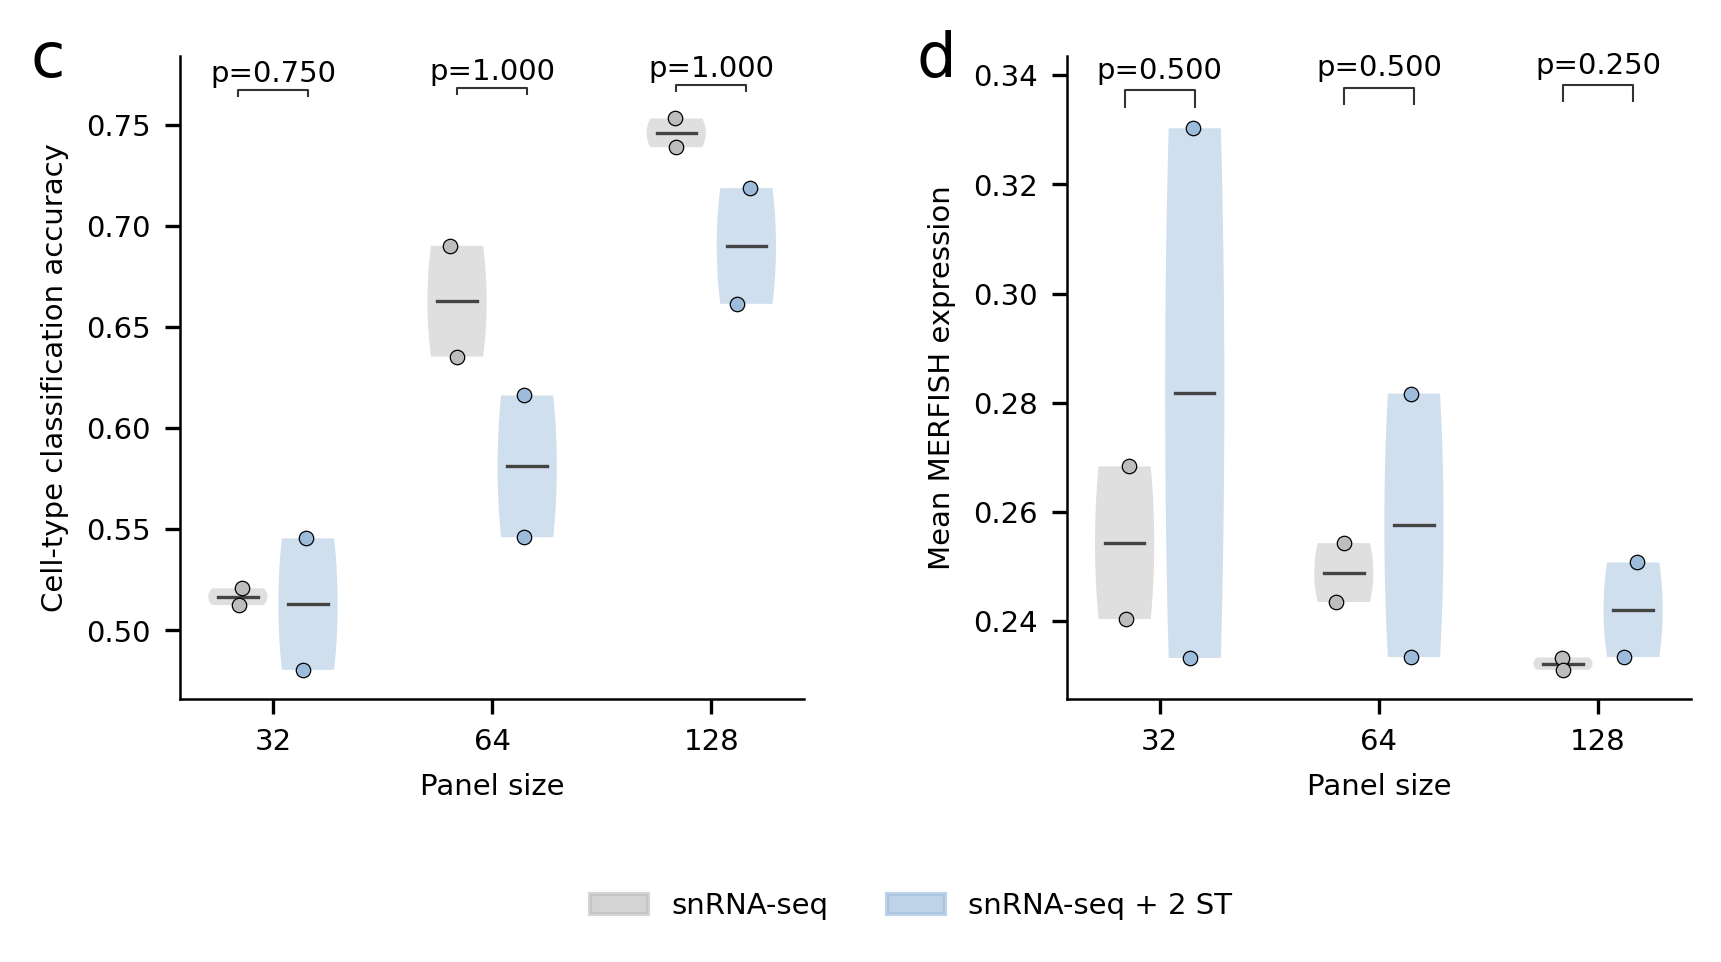

Editable exports: /workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/agent/figures/figure6_c_d_reproduced.pdf /workspace/fanyimin/SMITH_package/outputs/figure_tutorials_v2/agent/figures/figure6_c_d_reproduced.svg


In [5]:
figure_prefix = CASE_OUTPUT / 'figures/figure6_c_d_reproduced'
plot_command = [sys.executable, str(ROOT / 'reproducibility/workflows/agent/plot_figure6.py'), '--accuracy', str(CASE_OUTPUT / 'figure_data/figure6_c_cell_type_accuracy.tsv'), '--expression', str(CASE_OUTPUT / 'figure_data/figure6_d_merfish_expression.tsv'), "--output-prefix", str(figure_prefix)]
subprocess.run(plot_command, cwd=ROOT, check=True)
display(Image(filename=str(figure_prefix.with_suffix(".png"))))
print("Editable exports:", figure_prefix.with_suffix(".pdf"), figure_prefix.with_suffix(".svg"))


## Full manuscript command

Append the following paper-scale arguments to the workflow command:

```text
--panel-sizes 32,64,128 --training-seeds 1,2,3,4,5 --epochs 200 (omit --reference to use all five manifest-listed defaults)
```

This hosted run uses two real spatial references and two training seeds. The manuscript Figure 6c-d command uses five retrieved liver references and five training seeds. Figure 6e-j requires external probe-design backends and the validation-guided HPO run; this notebook does not fabricate those panels.